# Sales Analytics Dashboard

## Dashboard Overview

This notebook develops an interactive business intelligence dashboard using
the cleaned Superstore sales data.

The dashboard summarizes key business performance indicators and provides
interactive visualizations for sales, profitability, customers, products,
and sales trends.

The dashboard developed in this notebook also provides the analytical
foundation for the Flask web application's dashboard.

In [ ]:
##IMPORTING LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

print("Libraries imported successfully!")

In [ ]:
##LOAD DATASET
df_clean = pd.read_csv("../data/raw/superstore.csv", encoding="cp1252")

print("Data loaded successfully!")

# Dashboard KPIs

The dashboard KPIs provide a high-level summary of sales performance, profitability, order volume, and customer purchasing behaviour.

In [ ]:
##CALCULATING THE KPIs
# ==============================
# DASHBOARD KPI CALCULATIONS
# ==============================

total_sales = df_clean["Sales"].sum()

total_profit = df_clean["Profit"].sum()

total_quantity = df_clean["Quantity"].sum()

total_orders = df_clean["Order ID"].nunique()

profit_margin = (total_profit / total_sales) * 100

average_order_value = total_sales / total_orders

print("Total Sales:", total_sales)
print("Total Profit:", total_profit)
print("Total Quantity:", total_quantity)
print("Total Orders:", total_orders)
print("Profit Margin:", profit_margin)
print("Average Order Value:", average_order_value)

In [ ]:
##UNIQUE ORDERS
df_clean["Order ID"].nunique()

In [ ]:
##FORMATTING THE NUMBERS
print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Total Quantity: {total_quantity:,}")
print(f"Total Orders: {total_orders:,}")
print(f"Profit Margin: {profit_margin:.2f}%")
print(f"Average Order Value: ${average_order_value:,.2f}")

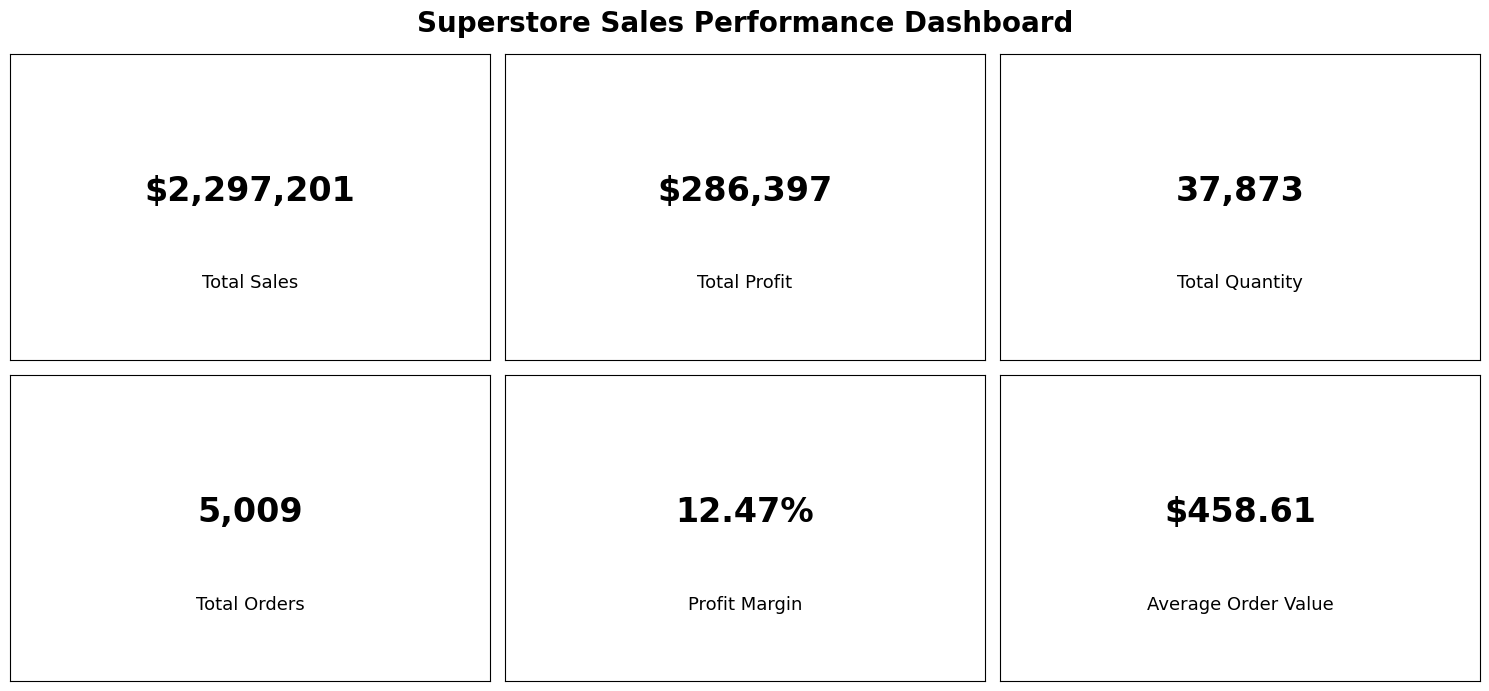

In [6]:
##CREATING THE ACTUAL KPI DASHBOARD
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(15, 7))

kpis = [
    ("Total Sales", f"${total_sales:,.0f}"),
    ("Total Profit", f"${total_profit:,.0f}"),
    ("Total Quantity", f"{total_quantity:,}"),
    ("Total Orders", f"{total_orders:,}"),
    ("Profit Margin", f"{profit_margin:.2f}%"),
    ("Average Order Value", f"${average_order_value:,.2f}")
]

for ax, (title, value) in zip(axes.flat, kpis):

    ax.text(
        0.5,
        0.55,
        value,
        ha="center",
        va="center",
        fontsize=24,
        fontweight="bold"
    )

    ax.text(
        0.5,
        0.25,
        title,
        ha="center",
        va="center",
        fontsize=13
    )

    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle(
    "Superstore Sales Performance Dashboard",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [7]:
##SALES GROWTH KPI

df_clean["Order Date"] = pd.to_datetime(df_clean["Order Date"])
df_clean["Year"] = df_clean["Order Date"].dt.year

In [ ]:
##YEARLY SALES
yearly_sales = (
    df_clean
    .groupby("Year", as_index=False)["Sales"]
    .sum()
    .sort_values("Year")
)

yearly_sales

In [ ]:
##SALES GROWTH CALCULATION

latest_year = yearly_sales["Year"].max()
previous_year = latest_year - 1

latest_sales = yearly_sales.loc[yearly_sales["Year"] == latest_year, "Sales"].values[0]
previous_sales = yearly_sales.loc[yearly_sales["Year"] == previous_year, "Sales"].values[0]

sales_growth = ((latest_sales - previous_sales) / previous_sales) * 100

print(f"Sales Growth: {sales_growth:.2f}%")

# Plotly Visualization

In [10]:
##CONVERTING ORDER DATE AND SHIP DATE TO DATETIME
df_clean["Order Date"] = pd.to_datetime(
    df_clean["Order Date"]
)

df_clean["Ship Date"] = pd.to_datetime(
    df_clean["Ship Date"]
)

In [11]:
##CREATING KPI CALCULATIONS
total_sales = df_clean["Sales"].sum()

total_profit = df_clean["Profit"].sum()

total_quantity = df_clean["Quantity"].sum()

total_orders = df_clean["Order ID"].nunique()

profit_margin = (
    total_profit / total_sales
) * 100

average_order_value = (
    total_sales / total_orders
)

In [ ]:
print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Total Quantity: {total_quantity:,}")
print(f"Total Orders: {total_orders:,}")
print(f"Profit Margin: {profit_margin:.2f}%")
print(f"Average Order Value: ${average_order_value:,.2f}")

In [14]:
##CREATING MONTHLY SALES GRAPH WITH PLOTLY
monthly_sales = (
    df_clean
    .set_index("Order Date")
    .resample("MS")["Sales"]
    .sum()
    .reset_index()
)


In [15]:
##MAKING THE GRAPH MORE PROFFESIONAL BY ADDING MARKERS
fig = px.line(
    monthly_sales,
    x="Order Date",
    y="Sales",
    title="Monthly Sales Trend",
    markers=True
)

fig.update_layout(
    xaxis_title="Date",
    yaxis_title="Total Sales"
)

fig.show()

In [16]:
##MAKING THE GRAPH MORE PROFFESIONAL BY ADDING MARKERS
fig = px.line(
    monthly_sales,
    x="Order Date",
    y="Sales",
    title="Monthly Sales Trend",
    markers=True
)

fig.update_layout(
    xaxis_title="Date",
    yaxis_title="Total Sales",
    template="plotly_white"
)

fig.show()

In [17]:
##CREATING SALES BY CATEGORY
category_sales = (
    df_clean
    .groupby("Category", as_index=False)["Sales"]
    .sum()
    .sort_values("Sales", ascending=False)
)

In [18]:

##CREATING BAR CHART FOR SALES BY CATEGORY
fig = px.bar(
    category_sales,
    x="Category",
    y="Sales",
    title="Total Sales by Product Category",
    text_auto=".2s"
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Category",
    yaxis_title="Total Sales"
)

fig.show()

In [19]:
##CREATING SALES BY SUB CATEGORY 
subcategory_sales = (
    df_clean
    .groupby("Sub-Category", as_index=False)["Sales"]
    .sum()
    .sort_values("Sales")
)

In [20]:
##CREATING BAR CHART FOR SALES BY SUB-CATEGORY
fig = px.bar(
    subcategory_sales,
    x="Sales",
    y="Sub-Category",
    orientation="h",
    title="Total Sales by Sub-Category",
    text_auto=".2s"
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Total Sales",
    yaxis_title="Sub-Category"
)

fig.show()

In [21]:
##CREATING THE PROFIT BY CATEGORY USING PLOTLY
category_profit = (
    df_clean
    .groupby("Category", as_index=False)["Profit"]
    .sum()
    .sort_values("Profit", ascending=False)
)

In [22]:
##CREATING BAR CHART FOR PROFIT BY CATEGORY
fig = px.bar(
    category_profit,
    x="Category",
    y="Profit",
    title="Total Profit by Product Category",
    text_auto=".2s"
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Category",
    yaxis_title="Total Profit"
)

fig.show()

In [23]:
##CREATING SALES BY SEGMENT USING PLOTLY
segment_sales = (
    df_clean
    .groupby("Segment", as_index=False)["Sales"]
    .sum()
    .sort_values("Sales", ascending=False)
)

In [24]:
##CREATING BAR CHART FOR SALES BY SEGMENT
fig = px.bar(
    segment_sales,
    x="Segment",
    y="Sales",
    title="Sales by Customer Segment",
    text_auto=".2s"
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Customer Segment",
    yaxis_title="Total Sales"
)

fig.show()

In [25]:
##NOW CREATING KPI CARDS USING PLOTLY using the go.Indicator function
##TOTAL SALES
fig = go.Figure()

fig.add_trace(
    go.Indicator(
        mode="number",
        value=total_sales,
        title={"text": "Total Sales"},
        number={
            "prefix": "$",
            "valueformat": ",.0f"
        }
    )
)

fig.update_layout(
    template="plotly_white",
    height=250
)

fig.show()

In [26]:
##NOW CREATING KPI CARDS USING PLOTLY using the go.Indicator function
##TOTAL PROFIT
fig = go.Figure()

fig.add_trace(
    go.Indicator(
        mode="number",
        value=total_profit,
        title={"text": "Total Profit"},
        number={
            "prefix": "$",
            "valueformat": ",.0f"
        }
    )
)

fig.update_layout(
    template="plotly_white",
    height=250
)

fig.show()

In [27]:
##NOW CREATING KPI CARDS USING PLOTLY using the go.Indicator function
##TOTAL ORDERS
fig = go.Figure()

fig.add_trace(
    go.Indicator(
        mode="number",
        value=total_orders,
        title={"text": "Total Orders"},
        number={
            "valueformat": ",.0f"
        }
    )
)

fig.update_layout(
    template="plotly_white",
    height=250
)

fig.show()

In [28]:
##NOW CREATING KPI CARDS USING PLOTLY using the go.Indicator function
##TOTAL QUANTITY
fig = go.Figure()

fig.add_trace(
    go.Indicator(
        mode="number",
        value=total_quantity,
        title={"text": "Total Quantity"},
        number={
            "valueformat": ",.0f"
        }
    )
)

fig.update_layout(
    template="plotly_white",
    height=250
)

fig.show()

In [32]:
##NOW CREATING KPI CARDS USING PLOTLY using the go.Indicator function
##PROFIT MARGIN
fig = go.Figure()

fig.add_trace(
    go.Indicator(
        mode="number",
        value=profit_margin,
        title={"text": "Profit Margin"},
        number={
            "suffix": "%",
            "valueformat": ".2f"
        },
        domain={"row": 1, "column": 1}
    )
)

fig.update_layout(
    template="plotly_white",
    height=250
)

fig.show()

In [31]:
##NOW CREATING KPI CARDS USING PLOTLY using the go.Indicator function
##AVERAGE ORDER VALUE
fig = go.Figure()

fig.add_trace(
    go.Indicator(
        mode="number",
        value=average_order_value,
        title={"text": "Average Order Value"},
        number={
            "prefix": "$",
            "valueformat": ",.2f"
        }
    )
)

fig.update_layout(
    template="plotly_white",
    height=250
)

fig.show()